In [1]:
#!/usr/bin/env python
import sys, glob, os
from pathlib import Path
import numpy as np
import numpy.ma as ma
from matplotlib import pyplot as plt
import xarray as xr
import MITgcmutils as MIT
sys.path.append('/albedo/home/nmamnun/miniconda3/ECCOv4-py')
import ecco_v4_py as ecco

In [2]:
iter_null =  710064
step_beetween_first_obs = 26460 
first_iter_obs = iter_null + step_beetween_first_obs
obs_iters = np.arange(first_iter_obs, first_iter_obs+360*73, 360)

In [3]:
freerun_dir = '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/REF_FRE'

In [4]:
Surf_TotChl_freerun = []
for iter in obs_iters:
    TotChl = MIT.rdmds(os.path.join(freerun_dir,'TotChl_ana'), iter)
    TotChl = TotChl[0]
    TotChl = ecco.llc_compact_to_tiles(TotChl)    
    Surf_TotChl_freerun.append(TotChl)
Surf_TotChl_freerun = np.array(Surf_TotChl_freerun)
print(Surf_TotChl_freerun.shape)

llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_c

In [5]:
def calculate_monthly_averages(data_5day):
    # Assuming you have data_5day with shape (73, num_tiles, num_lat, num_lon)
    num_time_steps, num_tiles, num_lat, num_lon = data_5day.shape
    num_months = 12  # Number of months in a year

    # Define the start and end indices for each month
    month_indices = [
        (0, 6), (6, 12), (12, 18), (18, 24), (24, 30), (30, 36),
        (36, 42), (42, 49), (49, 55), (55, 61), (61, 67), (67, 73)
    ]

    # Calculate the monthly averages
    monthly_average = np.zeros((num_months, num_tiles, num_lat, num_lon))
    for month_idx, (start_idx, end_idx) in enumerate(month_indices):
        monthly_average[month_idx] = np.nanmean(data_5day[start_idx:end_idx], axis=0)

    return monthly_average

In [6]:
with np.errstate(divide='ignore', invalid='ignore'):
    Surf_TotChl_freerun_ln = np.log(Surf_TotChl_freerun)
    Surf_TotChl_freerun_ln_monthly = calculate_monthly_averages(Surf_TotChl_freerun_ln)

In [7]:
assim_dir = '/albedo/work/projects/p_recompdaf/nmamnun/DAOUTPUTS/JSPE'

In [8]:
Surf_TotChl_je_for = []
for iter in obs_iters:
    TotChl = MIT.rdmds(os.path.join(assim_dir,'TotChl_for'), iter)
    TotChl = TotChl[0]
    TotChl = ecco.llc_compact_to_tiles(TotChl)    
    Surf_TotChl_je_for.append(TotChl)
Surf_TotChl_je_for = np.array(Surf_TotChl_je_for)
print(Surf_TotChl_je_for.shape)

llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_c

In [9]:
Surf_TotChl_je_ana = []
for iter in obs_iters:
    TotChl = MIT.rdmds(os.path.join(assim_dir,'TotChl_ana'), iter)
    TotChl = TotChl[0]
    TotChl = ecco.llc_compact_to_tiles(TotChl)    
    Surf_TotChl_je_ana.append(TotChl)
Surf_TotChl_je_ana = np.array(Surf_TotChl_je_ana)
print(Surf_TotChl_je_ana.shape)

llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_c

In [10]:
obs_schla = []
for iter in obs_iters:
    schla = MIT.rdmds(os.path.join(assim_dir,'schla_'), iter)
    schla = ecco.llc_compact_to_tiles(schla)
    obs_schla.append(schla)
    
obs_schla = np.array(obs_schla)
print(obs_schla.shape)
obs_schla[obs_schla>99.0] = np.nan

llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_compact_to_faces: dims, llc  (1170, 90) 90
llc_compact_to_faces: data_compact array type  float64
llc_faces_to_tiles: data_tiles shape  (13, 90, 90)
llc_faces_to_tiles: data_tiles dtype  float64
llc_c

In [11]:
with np.errstate(divide='ignore', invalid='ignore'):
    obs_schla_ln = np.log(obs_schla)
    obs_schla_ln_monthly = calculate_monthly_averages(obs_schla_ln) 

/tmp/ipykernel_1104779/3277820127.py:15: RuntimeWarning: Mean of empty slice
  monthly_average[month_idx] = np.nanmean(data_5day[start_idx:end_idx], axis=0)


In [12]:
with np.errstate(divide='ignore', invalid='ignore'):
    Surf_TotChl_je_ana_ln = np.log(Surf_TotChl_je_ana) 
    Surf_TotChl_je_ana_ln_monthly = calculate_monthly_averages(Surf_TotChl_je_ana_ln)

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyresample as pr

def plot_llc90_global(lons, lats, data,
                      ax=None,
                      user_lat_0=45,
                      projection_type='robin',
                      plot_type='pcolor',
                      user_lon_0=0,
                      background_type='fc',
                      show_cbar_label=False,
                      show_colorbar=False,
                      colorbar_extend='neither',
                      cbar_label='',
                      bound_lat=50,
                      num_levels=20,
                      cmap='viridis',
                      dx=0.5,
                      dy=0.5,
                      show_grid_lines=True,
                      norm=None,
                      **kwargs):
    '''
    Plot MITgcm llc90 outputs.

    lons: DataArray with shape (13, 90, 90) (e.g., dataset.XC)
    lats: DataArray with shape (13, 90, 90) (e.g., dataset.YC)
    data: DataArray with shape (13, 90, 90)

    Optional arguments:
      user_lat_0: Latitude at which to center the projection (default 45)
      projection_type: Type of projection (default 'robin')
      plot_type: Type of plot (default 'pcolor')
      user_lon_0: Longitude at which to center the projection (default 0)
      background_type: Type of background (default 'fc')
      show_cbar_label: Whether to show colorbar label (default False)
      show_colorbar: Whether to show colorbar (default False)
      colorbar_extend: Colorbar extension (default 'neither')
      cbar_label: Label for colorbar (default '')
      bound_lat: Bounding latitude for polar projections (default 50)
      num_levels: Number of intervals for colorbar (default 20)
      cmap: Colormap name (default 'viridis')
      dx: Interpolate resolution for longitude (default 0.5)
      dy: Interpolate resolution for latitude (default 0.5)
      show_grid_lines: Whether to show grid lines (default True)
      norm: Colormap normalization (default None)
      **kwargs: Additional keyword arguments (e.g., cmin, cmax)

    Returns:
      f: The figure object
      ax: The map axis
      im: The image (mappable) object
    '''

    # Determine min and max value of data; override with kwargs if provided
    cmin = np.nanmin(data)
    cmax = np.nanmax(data)
    for key in kwargs:
        if key == "cmin":
            cmin = kwargs[key]
        elif key == "cmax":
            cmax = kwargs[key]
        else:
            print("unrecognized argument ", key)

    # Process lons and lats: flatten to 1D arrays if needed
    if isinstance(lons, xr.core.dataarray.DataArray):
        lons_1d = lons.values.reshape(np.product(lons.values.shape))
        lats_1d = lats.values.reshape(np.product(lats.values.shape))
    elif isinstance(lons, np.ndarray):
        lons_1d = lons.reshape(np.product(lons.shape))
        lats_1d = lats.reshape(np.product(lats.shape))
    else:
        print('lons and lats must be either a DataArray or a numpy.ndarray')
        return

    if isinstance(data, xr.core.dataarray.DataArray):
        data = data.values
    elif not (isinstance(data, np.ndarray) or isinstance(data, np.ma.core.MaskedArray)):
        print('data must be either a DataArray or ndarray type')
        return

    if ax is None:
        f = plt.figure(figsize=(12, 9), dpi=90)
        if projection_type == 'plate':
            ax = f.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=user_lon_0))
            ax.set_global()
        elif projection_type == 'robin':
            ax = f.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=user_lon_0))
            ax.set_global()
        elif projection_type == 'ortho':
            ax = f.add_subplot(1, 1, 1, projection=ccrs.Orthographic(central_longitude=user_lon_0,
                                                                     central_latitude=user_lat_0))
            ax.set_global()
        elif projection_type == 'mollweide':
            ax = f.add_subplot(1, 1, 1, projection=ccrs.Mollweide(central_longitude=user_lon_0))
            ax.set_global()
        elif projection_type == 'stereo':
            if bound_lat > 0:
                ax = f.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo(central_longitude=user_lon_0))
                ax.set_extent([-180.0, 180.0, bound_lat, 90.0],
                              crs=ccrs.PlateCarree())
            else:
                ax = f.add_subplot(1, 1, 1, projection=ccrs.SouthPolarStereo(central_longitude=user_lon_0))
                ax.set_extent([-180.0, 180.0, bound_lat, -90.0],
                              crs=ccrs.PlateCarree())
        else:
            raise ValueError('projection_type must be "plate", "robin", "ortho", "mollweide" or "stereo"')
    else:
        f = plt.gcf()  

    f.canvas.draw()
    if background_type == 'fc':
        ax.add_feature(cfeature.LAND, facecolor='peru', zorder=0)
    elif background_type == 'stock':
        ax.stock_img()
        

    if not hasattr(ax, 'coastlines'):
        raise AttributeError("The provided axis does not have a 'coastlines' method. "
                             "Make sure to create the axis with a Cartopy projection, for example:\n"
                             "fig, axs = plt.subplots(..., subplot_kw={'projection': ccrs.Robinson(central_longitude=user_lon_0)})")
    ax.coastlines(resolution='110m')

 
    orig_grid = pr.geometry.SwathDefinition(lons=lons_1d, lats=lats_1d)
    lat_tmp = np.arange(-90.0, 90.0 + dy, dy)
    lon_tmp = np.arange(-180.0, 180.0 + dx, dx)
    new_grid_lon, new_grid_lat = np.meshgrid(lon_tmp, lat_tmp)
    new_grid = pr.geometry.GridDefinition(lons=new_grid_lon, lats=new_grid_lat)
    data_latlon_projection = pr.kd_tree.resample_nearest(orig_grid, data, new_grid,
                                                          radius_of_influence=100000,
                                                          fill_value=None)

    # Create the plot using either pcolor or contourf.
    if plot_type == 'pcolor':
        im = ax.pcolormesh(new_grid_lon, new_grid_lat, data_latlon_projection,
                           vmin=cmin, vmax=cmax, transform=ccrs.PlateCarree(),
                           cmap=cmap, norm=norm)
    elif plot_type == 'contourf':
        contour_levels = np.linspace(cmin, cmax, num_levels)
        im = ax.contourf(new_grid_lon, new_grid_lat, data_latlon_projection,
                         vmin=cmin, vmax=cmax, transform=ccrs.PlateCarree(),
                         cmap=cmap, norm=norm,
                         levels=contour_levels, extend=colorbar_extend)
    else:
        print('plot type must be either "pcolor" or "contourf"')
        return

    # Add grid lines if requested.
    if projection_type == 'plate' and show_grid_lines:
        ax.gridlines(draw_labels=True, color='dimgray', linestyle='--', zorder=3)
    elif show_grid_lines:
        ax.gridlines(draw_labels=False, color='dimgray', linestyle='--', zorder=3)


    if show_colorbar:
        f.subplots_adjust(right=0.8)
        h = 0.6
        w = 0.025
        cbar_ax = f.add_axes([0.85, (1 - h) / 2, w, h])
        cbar = f.colorbar(im, extend=colorbar_extend, cax=cbar_ax)
        if show_cbar_label:
            cbar.set_label(cbar_label)

    plt.sca(ax)  
    return f, ax, im

In [14]:
import xarray as xr
llc90_grid = xr.open_dataset('llc90_grid.nc')

def mask_data(data, time_dependent=False):
    # Extract the mask from the llc90_grid
    mask = llc90_grid.hFacC.values

    # Check if the mask is of the shape (50, 13, 90, 90)
    if mask.shape != (50, 13, 90, 90):
        raise ValueError("The provided grid is not an llc90 grid.")

    # Check dimensions of the data and apply the mask accordingly
    if time_dependent:
        if data.shape[1:] == (50, 13, 90, 90):
            # Extend the mask along the time dimension
            extended_mask = np.tile(mask, (data.shape[0], 1, 1, 1, 1))
            masked_data = ma.masked_where(extended_mask == 0, data)
        elif data.shape[1:] == (13, 90, 90):
            # Use only the first slice of the mask and extend along time dimension
            extended_mask = np.tile(mask[0], (data.shape[0], 1, 1, 1))
            masked_data = ma.masked_where(extended_mask == 0, data)
        else:
            raise ValueError(
                "Data dimensions with time do not match the expected shape.")
    else:
        if data.shape == (50, 13, 90, 90):
            masked_data = ma.masked_where(mask == 0, data)
        elif data.shape == (13, 90, 90):
            masked_data = ma.masked_where(mask[0] == 0, data)
        else:
            raise ValueError(
                "Data dimensions do not match the expected shape.")

    return masked_data

In [15]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

def make_colormap_custom_rainbow():
    """
    Return a LinearSegmentedColormap
    seq: a sequence of floats and RGB-tuples. The floats should be increasing
    and in the interval (0,1).
    """

    c = mcolors.ColorConverter().to_rgb

    seq = [(0.10588235294117647, 0.0, 0.17647058823529413),
           (0.5098039215686274, 0.0, 0.6666666666666666), 0.125,
           (0.5098039215686274, 0.0, 0.6666666666666666),
           c('blue'), 0.25,
           c('blue'),
           c('cyan'), 0.375,
           c('cyan'),
           c('green'), 0.5,
           c('green'), (0.0, 1.0, 0.0), 0.5625, (0.0, 1.0, 0.0),
           c('yellow'), 0.625,
           c('yellow'),
           c('red'), 0.75,
           c('red'), (0.5607843137254902, 0.0, 0.2627450980392157), 0.875,
           (0.5607843137254902, 0.0, 0.2627450980392157),
           (0.23529411764705882, 0.0, 0.0)]

    seq = [(None, ) * 3, 0.0] + list(seq) + [1.0, (None, ) * 3]

    cdict = {'red': [], 'green': [], 'blue': []}

    for i, item in enumerate(seq):
        if isinstance(item, float):
            r1, g1, b1 = seq[i - 1]
            r2, g2, b2 = seq[i + 1]
            cdict['red'].append([item, r1, r2])
            cdict['green'].append([item, g1, g2])
            cdict['blue'].append([item, b1, b2])

    return mcolors.LinearSegmentedColormap('CustomMap', cdict)


def make_colormap_custom_nipyspectral():
    """
    """
    tmpnipy = plt.cm.nipy_spectral(np.linspace(0., 1, 269))
    nipy2 = tmpnipy[0:255]
    return mcolors.LinearSegmentedColormap.from_list('my_colormap', nipy2)

cmapnipa = make_colormap_custom_nipyspectral()

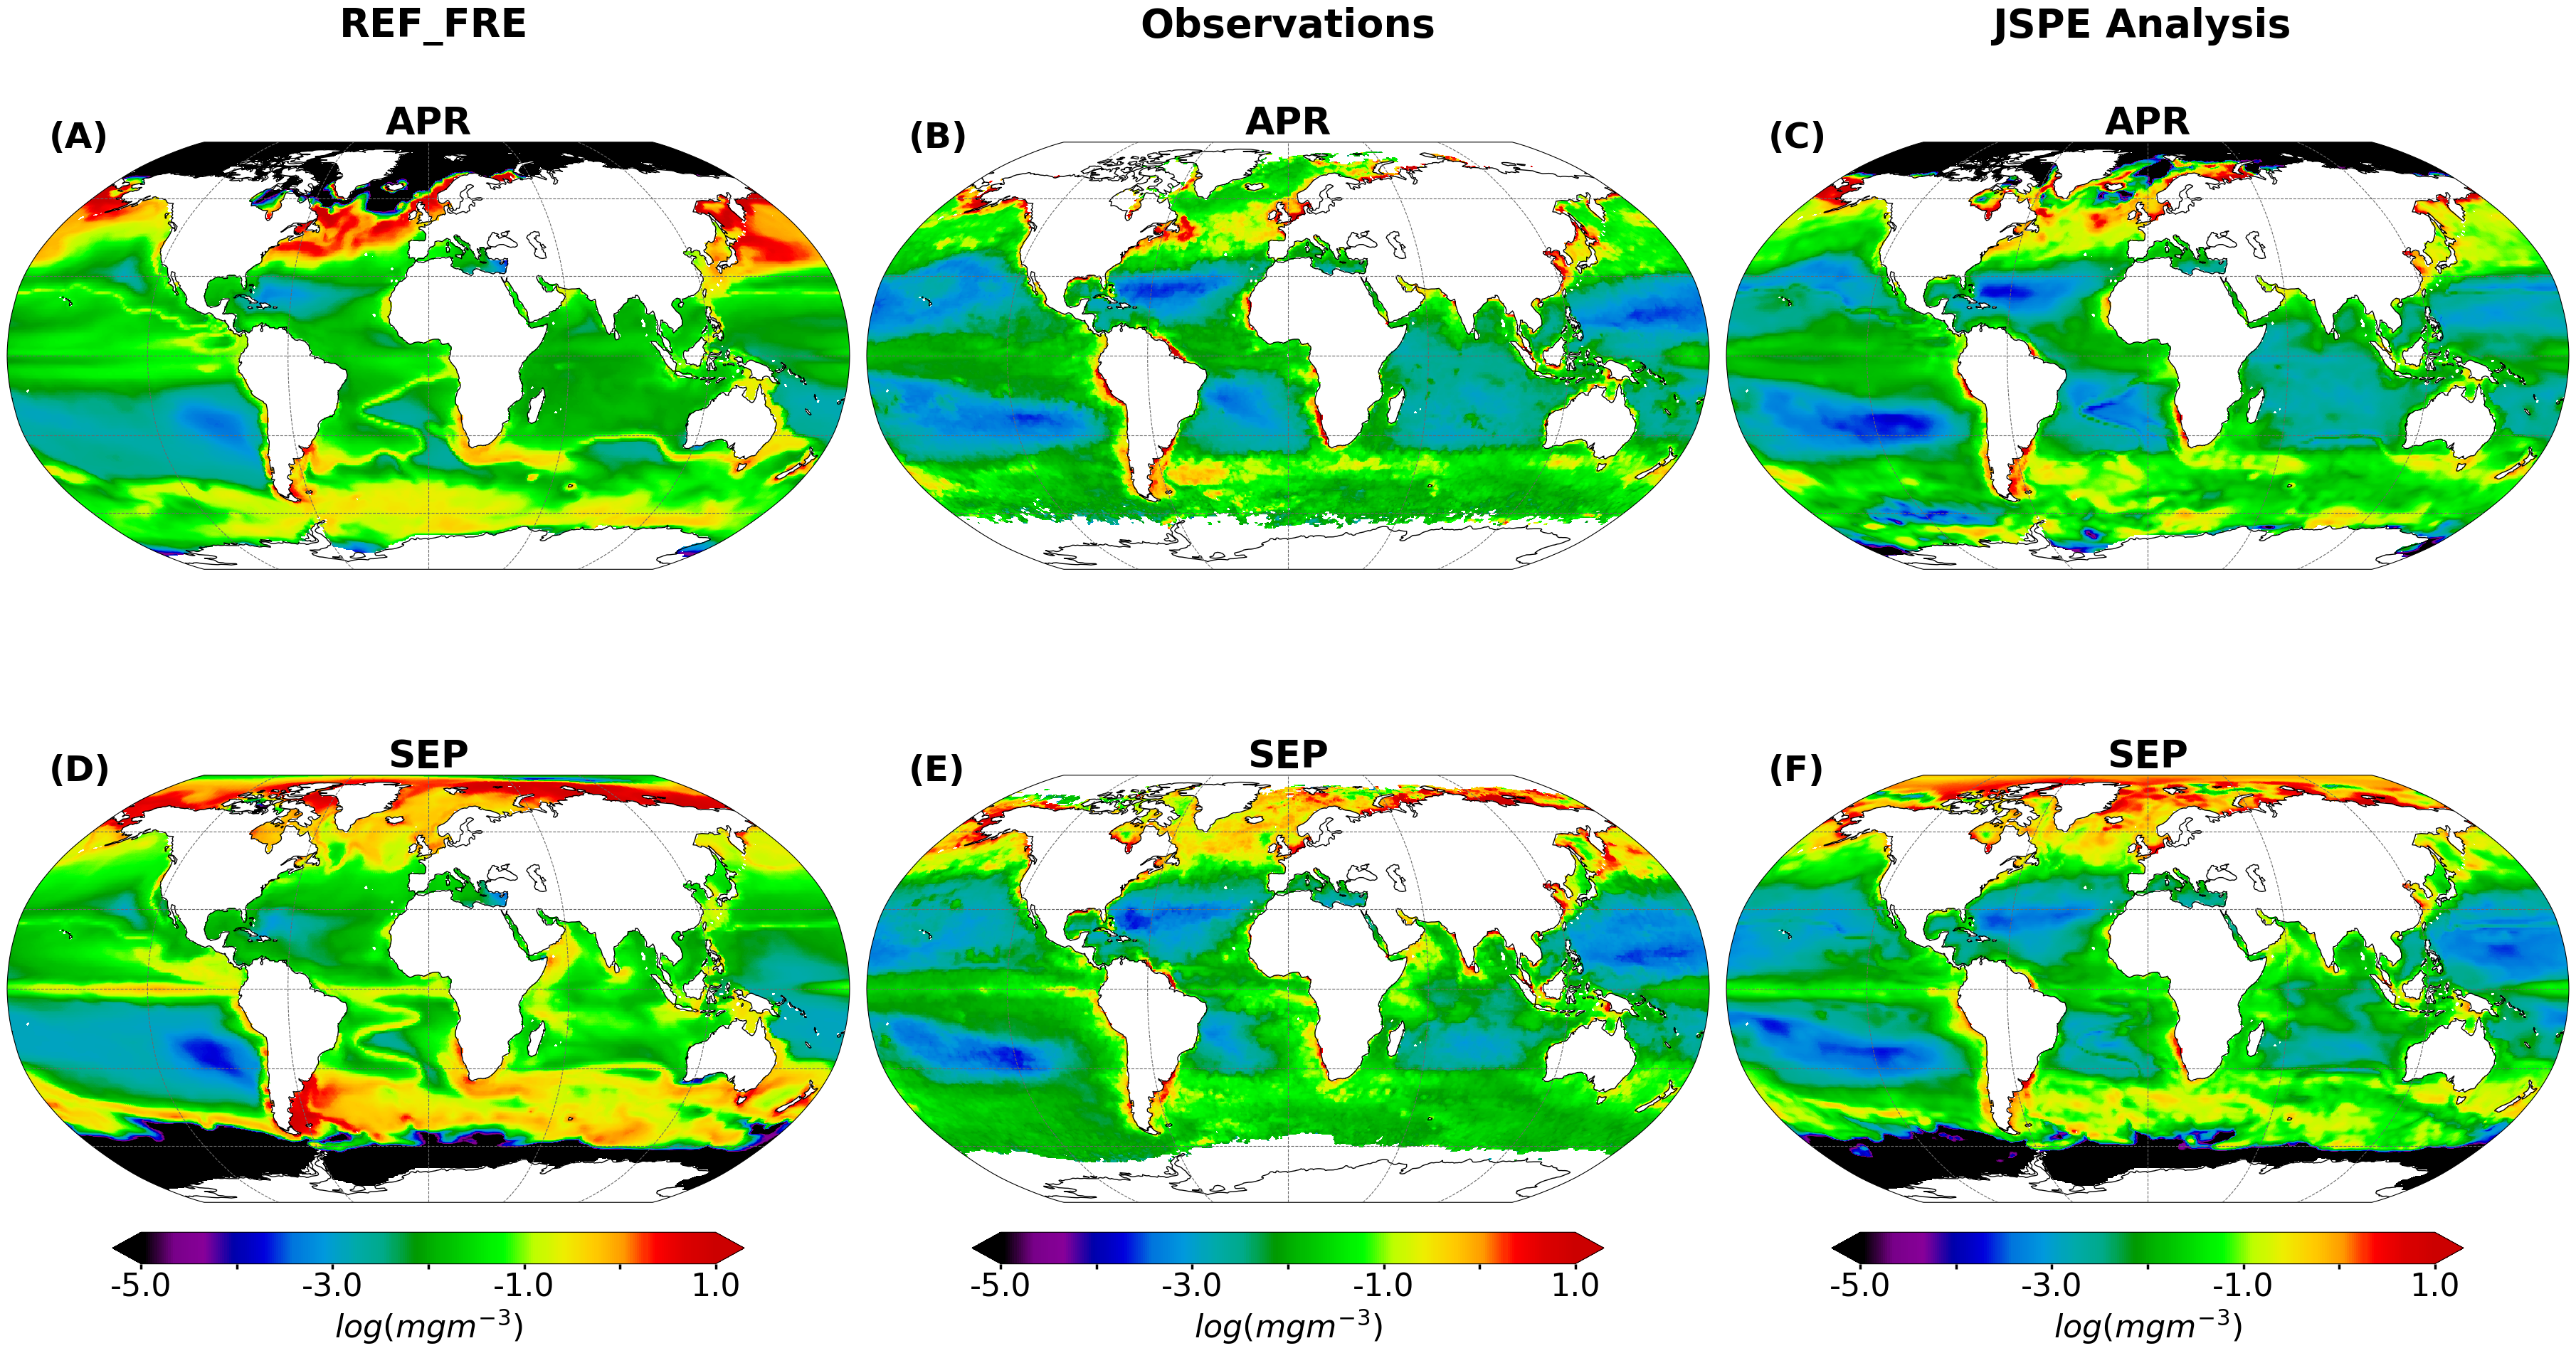

In [16]:
plt.rcParams.update({'font.size': 32})
plt.rcParams['figure.facecolor'] = 'white'

cmin = -5.0; cmax = 1.0; num_levels = 256
cbar_label = r'$log(mg m^{-3})$'
cbar_ticks = [-5., -4., -3., -2., -1., 0., 1.]
cbar_ticklabels = ['-5.0','','-3.0','','-1.0','','1.0']


fig, axs = plt.subplots(2, 3, figsize=(36, 18),
                        constrained_layout=True,
                        subplot_kw={'projection': ccrs.Robinson(central_longitude=0.0)})
fig.set_constrained_layout_pads(w_pad=-0.3, h_pad=0.1, hspace=0.0)

################################
# Panel (A): APR – Surf_TotChl_freerun_ln_monthly[3]
################################
data_A = mask_data(Surf_TotChl_freerun_ln_monthly[3])
ax = axs[0, 0]

_, _, imA = plot_llc90_global(llc90_grid.XC, llc90_grid.YC, data_A,
                              ax=ax,
                              show_colorbar=False,
                              colorbar_extend='both',
                              cmap=cmapnipa,
                              num_levels=num_levels,
                              cmin=cmin,
                              cmax=cmax,
                              plot_type='contourf',
                              show_grid_lines=True,
                              background_type=None,
                              user_lon_0=0.0,
                              projection_type='robin')

ax.set_title('APR', pad=5, fontweight='bold')
ax.text(0.05, 1.05, '(A)', transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        fontsize=36, fontweight='bold')

################################
# Panel (B): APR – obs_schla_ln_monthly[3]
################################
data_B = mask_data(obs_schla_ln_monthly[3])
ax = axs[0, 1]
_, _, imB = plot_llc90_global(llc90_grid.XC, llc90_grid.YC, data_B,
                              ax=ax,
                              show_colorbar=False,
                              colorbar_extend='both',
                              cmap=cmapnipa,
                              num_levels=num_levels,
                              cmin=cmin,
                              cmax=cmax,
                              plot_type='contourf',
                              show_grid_lines=True,
                              background_type=None,
                              user_lon_0=0.0,
                              projection_type='robin')

ax.set_title('APR', pad=5, fontweight='bold')
ax.text(0.05, 1.05, '(B)', transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        fontsize=36, fontweight='bold')

################################
# Panel (C): APR – Surf_TotChl_je_ana_ln_monthly[3]
################################
data_C = mask_data(Surf_TotChl_je_ana_ln_monthly[3])
ax = axs[0, 2]
_, _, imC = plot_llc90_global(llc90_grid.XC, llc90_grid.YC, data_C,
                              ax=ax,
                              show_colorbar=False,
                              colorbar_extend='both',
                              cmap=cmapnipa,
                              num_levels=num_levels,
                              cmin=cmin,
                              cmax=cmax,
                              plot_type='contourf',
                              show_grid_lines=True,
                              background_type=None,
                              user_lon_0=0.0,
                              projection_type='robin')

ax.set_title('APR', pad=5, fontweight='bold')
ax.text(0.05, 1.05, '(C)', transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        fontsize=36, fontweight='bold')

################################
# Panel (D): SEP – Surf_TotChl_freerun_ln_monthly[8]
################################
data_D = mask_data(Surf_TotChl_freerun_ln_monthly[8])
ax = axs[1, 0]
_, _, imD = plot_llc90_global(llc90_grid.XC, llc90_grid.YC, data_D,
                              ax=ax,
                              show_colorbar=False,
                              colorbar_extend='both',
                              cmap=cmapnipa,
                              num_levels=num_levels,
                              cmin=cmin,
                              cmax=cmax,
                              plot_type='contourf',
                              show_grid_lines=True,
                              background_type=None,
                              user_lon_0=0.0,
                              projection_type='robin')
cbarD = fig.colorbar(imD, ax=ax, orientation='horizontal', shrink=0.75, pad=0.05)
cbarD.set_ticks(cbar_ticks)
cbarD.set_ticklabels(cbar_ticklabels)
cbarD.ax.tick_params(axis='x', which='both', width=2.5, length=5)
cbarD.set_label(cbar_label, labelpad=5)
ax.set_title('SEP', pad=5, fontweight='bold')
ax.text(0.05, 1.05, '(D)', transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        fontsize=36, fontweight='bold')

################################
# Panel (E): SEP – obs_schla_ln_monthly[8]
################################
data_E = mask_data(obs_schla_ln_monthly[8])
ax = axs[1, 1]
_, _, imE = plot_llc90_global(llc90_grid.XC, llc90_grid.YC, data_E,
                              ax=ax,
                              show_colorbar=False,
                              colorbar_extend='both',
                              cmap=cmapnipa,
                              num_levels=num_levels,
                              cmin=cmin,
                              cmax=cmax,
                              plot_type='contourf',
                              show_grid_lines=True,
                              background_type=None,
                              user_lon_0=0.0,
                              projection_type='robin')
cbarE = fig.colorbar(imE, ax=ax, orientation='horizontal', shrink=0.75, pad=0.05)
cbarE.set_ticks(cbar_ticks)
cbarE.set_ticklabels(cbar_ticklabels)
cbarE.ax.tick_params(axis='x', which='both', width=2.5, length=5)
cbarE.set_label(cbar_label, labelpad=5)
ax.set_title('SEP', pad=5, fontweight='bold')
ax.text(0.05, 1.05, '(E)', transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        fontsize=36, fontweight='bold')

################################
# Panel (F): SEP – Surf_TotChl_je_ana_ln_monthly[8]
################################
data_F = mask_data(Surf_TotChl_je_ana_ln_monthly[8])
ax = axs[1, 2]
_, _, imF = plot_llc90_global(llc90_grid.XC, llc90_grid.YC, data_F,
                              ax=ax,
                              show_colorbar=False,
                              colorbar_extend='both',
                              cmap=cmapnipa,
                              num_levels=num_levels,
                              cmin=cmin,
                              cmax=cmax,
                              plot_type='contourf',
                              show_grid_lines=True,
                              background_type=None,
                              user_lon_0=0.0,
                              projection_type='robin')
cbarF = fig.colorbar(imF, ax=ax, orientation='horizontal', shrink=0.75, pad=0.05)
cbarF.set_ticks(cbar_ticks)
cbarF.set_ticklabels(cbar_ticklabels)
cbarF.ax.tick_params(axis='x', which='both', width=2.5, length=5)
cbarF.set_label(cbar_label, labelpad=5)
ax.set_title('SEP', pad=5, fontweight='bold')
ax.text(0.05, 1.05, '(F)', transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        fontsize=36, fontweight='bold')

fig.text(1/6, 1.02, 'REF_FRE', ha='center', va='bottom', fontsize=40, fontweight='bold')
fig.text(0.50, 1.02, 'Observations', ha='center', va='bottom', fontsize=40, fontweight='bold')
fig.text(5/6, 1.02, 'JSPE Analysis', ha='center', va='bottom', fontsize=40, fontweight='bold')

plt.savefig("FIG_SCHL_COMPARISON.jpg", bbox_inches='tight', dpi=300)

plt.show()